# Approach 1 — guided design with the dual surrogate + oracle

Property-guided FP design wired to the models from `surrogate_model_design_dual.ipynb`:

- **Surrogate** = `dual_surrogate_net.pt` (best **MLP**, mlp-concat) — *guides* refinement.
- **Oracle** = `dual_oracle_net.pt` (best **CNN**, cnn-max) — independent *evaluator* (different architecture +
  different split; em-MAE ~3-5 nm where it judges).

Both predict **PCA coefficients**, reconstructed to spectra via their saved PCA bases. Using the dual labels
(`dual_splits.csv`) we design toward **in-sample** (surrogate-seen) and **OOD** (surrogate-unseen) targets, both
judged by the oracle, to compare in-sample vs out-of-distribution design capacity.

## 0. Setup + data + dual labels

In [1]:
import csv, os, numpy as np, torch, joblib
import arcadia_pycolor as apc, fp_models as fpm
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True; apc.mpl.setup()
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32); grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EMM=np.array([float(r["em_max"]) for r in rows]); EXM=np.array([float(r["ex_max"]) for r in rows])
seqs=[None]*N; h=None
for line in open(os.path.join(TD,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
dual=list(csv.DictReader(open(os.path.join(TD,"dual_splits.csv"))))
Srole=np.array([d["surrogate_role"] for d in dual]); Orole=np.array([d["oracle_role"] for d in dual])
print("device",dev,"| N",N,"| surrogate roles",{b:int((Srole==b).sum()) for b in('train','val','test')})

device mps | N 453 | surrogate roles {'train': 317, 'val': 68, 'test': 68}


## 1. Load dual models (+ PCA bases) and wire spectrum predictors

In [2]:
surrogate_net, s_meta = fpm.load_model(os.path.join("trained_models","dual_surrogate_net.pt"), dev)
oracle_net,    o_meta = fpm.load_model(os.path.join("trained_models","dual_oracle_net.pt"), dev)
surr_pca = joblib.load(os.path.join("trained_models","dual_surrogate_pca.joblib"))
orac_pca = joblib.load(os.path.join("trained_models","dual_oracle_pca.joblib"))
print(f"surrogate: {s_meta['sid']} (out={s_meta['out']} PCA coeffs) | val MSE {s_meta['metrics']['val']['mse']:.4f}")
print(f"oracle:    {o_meta['sid']} (out={o_meta['out']} PCA coeffs) | val MSE {o_meta['metrics']['val']['mse']:.4f}")

g_spectrum      = fpm.pca_spectrum_fn(surrogate_net, surr_pca, dev)   # GUIDANCE (reconstructs spectrum)
oracle_spectrum = fpm.pca_spectrum_fn(oracle_net,   orac_pca, dev)    # EVALUATION

esm_model, alphabet, bc = fpm.get_esm(dev)
AA_MASK = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
for a in "ACDEFGHIKLMNPQRSTVWY": AA_MASK[alphabet.get_idx(a)] = True
AA_MASK = AA_MASK.to(dev)
SPECIAL = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}

surrogate: mlp-concat (out=32 PCA coeffs) | val MSE 0.0291
oracle:    cnn-max (out=32 PCA coeffs) | val MSE 0.0241


## 2. Pseudo-perplexity (naturalness)

In [3]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    _,_,base=bc([("s",seq.strip().upper())]); base=base[0].to(dev)
    res=[i for i,t in enumerate(base.tolist()) if t not in SPECIAL]; tot=0.0
    for s in range(0,len(res),batch_size):
        ch=res[s:s+batch_size]; bt=base.unsqueeze(0).repeat(len(ch),1).clone()
        for r,p in enumerate(ch): bt[r,p]=alphabet.mask_idx
        lp=torch.log_softmax(esm_model(bt)["logits"],dim=-1)
        for r,p in enumerate(ch): tot+=float(lp[r,p,base[p]])
    n=len(res); return tot, float(np.exp(-tot/n))

## 3. Guided refinement (surrogate guides, oracle evaluates)

In [4]:
def to_tokens(seq): _,_,t=bc([("q",seq.strip().upper())]); return t.to(dev)
def tokens_to_seq(t1d): return "".join(alphabet.get_tok(int(x)) for x in t1d if int(x) not in SPECIAL)

@torch.no_grad()
def guided_refine(seq, target, n_sweeps=1, k=6, lam=5.0, temperature=0.0, editable=None, eval_fn=None, verbose=True):
    toks=to_tokens(seq)
    res=[i for i,t in enumerate(toks[0].tolist()) if t not in SPECIAL]
    if editable is not None: res=[res[j] for j in editable]
    tnorm=float(torch.sum(target**2))+1e-8; trace=[]
    for sweep in range(n_sweeps):
        for pos in res:
            toks[0,pos]=alphabet.mask_idx
            lg=esm_model(toks)["logits"][0,pos].masked_fill(~AA_MASK,float("-inf"))
            logp=torch.log_softmax(lg,-1); topv,topi=torch.topk(logp,k)
            cand=[]
            for idx in topi.tolist(): toks[0,pos]=idx; cand.append(tokens_to_seq(toks[0]))
            d=torch.sum((g_spectrum(cand)-target.unsqueeze(0))**2,1)/tnorm           # surrogate guidance
            lpz=(topv-topv.mean())/(topv.std()+1e-6); dz=(d-d.mean())/(d.std()+1e-6)
            scores=lpz-lam*dz
            ch=(torch.multinomial(torch.softmax(scores/temperature,-1),1).item() if temperature>0 else int(torch.argmax(scores)))
            toks[0,pos]=int(topi[ch].item())
        cur=tokens_to_seq(toks[0])
        ev=(eval_fn(cur)[0] if eval_fn is not None else g_spectrum(cur)[0])           # oracle evaluation
        err=float(torch.sum((ev-target)**2)/tnorm); trace.append(err)
        if verbose: print(f"  sweep {sweep}: oracle error {err:.4f}")
    return tokens_to_seq(toks[0]), trace

## 4. Design: in-sample vs OOD targets (oracle-judged)

Start from a green scaffold and design toward target spectra the **surrogate saw** (in-sample,
`surrogate_role==train`) vs **never saw** (OOD, `surrogate_role==test`), within ~70 nm of the scaffold for a
fair comparison. `FULL_REDESIGN=True` lets the loop edit **every** position (vs a fixed window). The oracle
judges; designs are saved to `designs/`.

In [5]:
REGENERATE=False     # True -> (re)generate designs; False -> reuse designs/designs.csv if present
N_PER=2; WINDOW=40; K_TOP=6; LAM=5.0; N_SWEEPS=1; FULL_REDESIGN=True
dpath=os.path.join("designs","designs.csv")

if REGENERATE or not os.path.exists(dpath):
    greens=np.where(np.abs(EMM-510)<15)[0]
    scaffold_idx=int(greens[np.argmin(np.abs(np.array([len(seqs[i]) for i in greens])-240))])
    scaffold=seqs[scaffold_idx]; Llen=len(scaffold); mid=Llen//2
    editable=None if FULL_REDESIGN else list(range(max(0,mid-WINDOW//2), min(Llen,mid+WINDOW//2)))
    sem=EMM[scaffold_idx]
    print(f"scaffold: {rows[scaffold_idx]['name']} (len {Llen}, em {sem:.0f}) | "
          f"{'FULL redesign (all positions)' if FULL_REDESIGN else f'window {WINDOW}'}")
    def pick(role,n):
        cand=sorted([i for i in range(N) if Srole[i]==role and i!=scaffold_idx and abs(EMM[i]-sem)<=70], key=lambda i: EMM[i])
        return [cand[int(x)] for x in np.linspace(0,len(cand)-1,min(n,len(cand)))] if cand else []
    def design_to(idxs,label):
        out=[]
        for i in idxs:
            t=torch.tensor(Y[i],device=dev); tn=float(torch.sum(t**2))+1e-8
            d0=float(torch.sum((oracle_spectrum(scaffold)[0]-t)**2)/tn)
            des,_=guided_refine(scaffold,t,n_sweeps=N_SWEEPS,k=K_TOP,lam=LAM,editable=editable,eval_fn=oracle_spectrum,verbose=False)
            d1=float(torch.sum((oracle_spectrum(des)[0]-t)**2)/tn); _,ppl=pseudo_perplexity(des)
            ident=sum(a==b for a,b in zip(des,scaffold))/len(scaffold)
            out.append(dict(idx=i,name=rows[i]["name"],em=EMM[i],draft=d0,refined=d1,ppl=ppl,design=des,label=label,ident=ident))
            print(f"[{label:9s}] {rows[i]['name'][:18]:18s} em{EMM[i]:.0f} | oracle {d0:.3f} -> {d1:.3f} | ppl {ppl:.1f} | id {ident:.2f}")
        return out
    ins=design_to(pick("train",N_PER),"in-sample"); ood=design_to(pick("test",N_PER),"OOD"); alld=ins+ood
    print(f"\nmean oracle error  in-sample: {np.mean([r['refined'] for r in ins]):.3f} | OOD: {np.mean([r['refined'] for r in ood]):.3f}")
    os.makedirs("designs", exist_ok=True)
    with open(dpath,"w",newline="") as fh:
        w=csv.writer(fh)
        w.writerow(["role","target_name","target_idx","target_em","scaffold","scaffold_idx","full_redesign",
                    "draft_err","refined_err","ppl","ident_to_scaffold","designed_seq","target_seq","scaffold_seq"])
        for d in alld:
            w.writerow([d["label"],d["name"],d["idx"],f"{d['em']:.0f}",rows[scaffold_idx]["name"],scaffold_idx,FULL_REDESIGN,
                        f"{d['draft']:.4f}",f"{d['refined']:.4f}",f"{d['ppl']:.2f}",f"{d['ident']:.3f}",
                        d["design"],seqs[d["idx"]],scaffold])
    with open(os.path.join("designs","designs.fasta"),"w") as fh:
        for d in alld: fh.write(f">{d['label']}|{d['name']}|em{d['em']:.0f}|err{d['refined']:.3f}\n{d['design']}\n")
    print(f"saved {len(alld)} designs -> {dpath} + designs/designs.fasta")
else:
    print(f"REGENERATE=False and {dpath} exists -> skipping generation; section 5 loads it.")

REGENERATE=False and designs/designs.csv exists -> skipping generation; section 5 loads it.


loaded 4 designs from designs/designs.csv


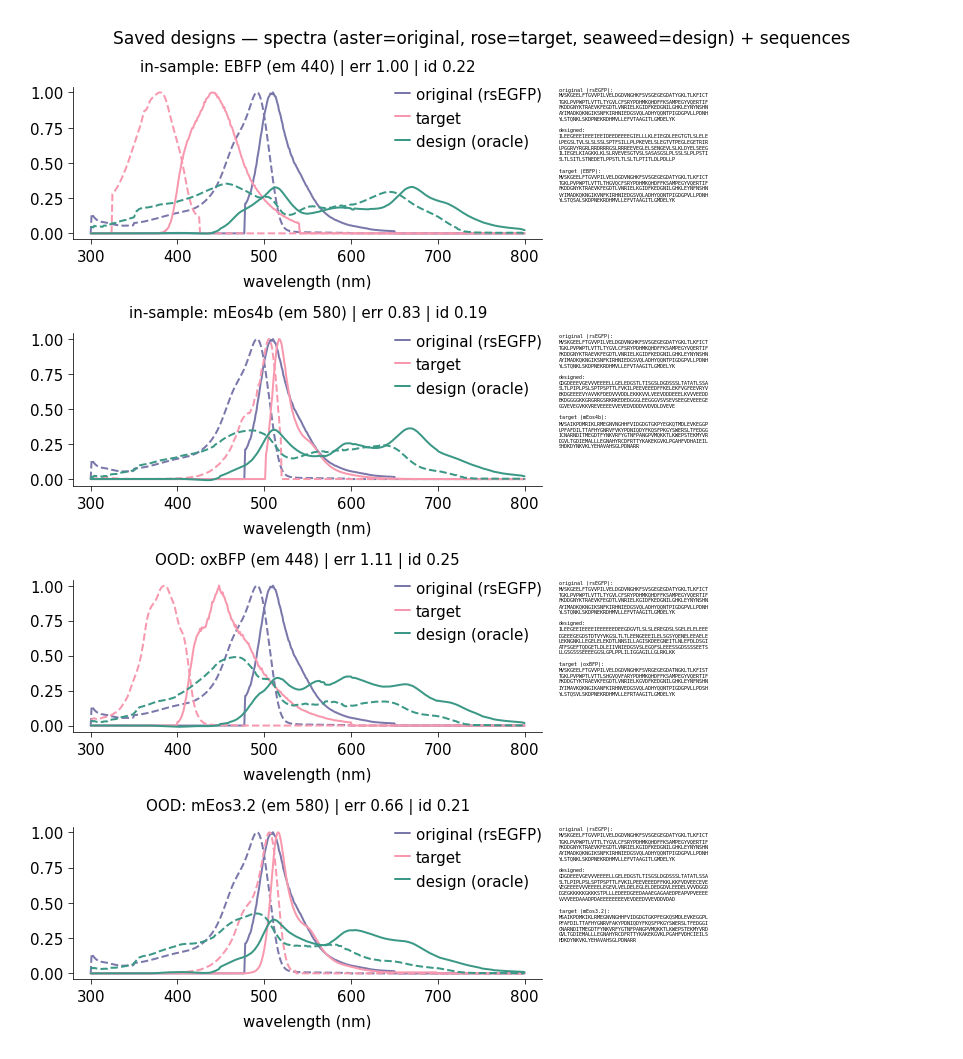

In [6]:
# Load the saved designs and visualize (independent of the generation step above)
recs=list(csv.DictReader(open(os.path.join("designs","designs.csv"))))
print(f"loaded {len(recs)} designs from designs/designs.csv")
if HAVE_PLT and recs:
    def wrap(s,w=50): return "\n".join(s[i:i+w] for i in range(0,len(s),w))
    n=len(recs); fig,axes=plt.subplots(n,2,figsize=(13,3.6*n),gridspec_kw={"width_ratios":[1.25,1]})
    if n==1: axes=axes.reshape(1,2)
    for r,d in enumerate(recs):
        ti=int(d["target_idx"]); si=int(d["scaffold_idx"])
        des=oracle_spectrum(d["designed_seq"])[0].cpu().numpy(); orig=Y[si]; tgt=Y[ti]
        aS,aT=axes[r,0],axes[r,1]
        aS.plot(grid,orig[:G],color=apc.aster,ls="--"); aS.plot(grid,orig[G:],color=apc.aster,ls="-",label=f"original ({d['scaffold']})")
        aS.plot(grid,tgt[:G],color=apc.rose,ls="--");  aS.plot(grid,tgt[G:],color=apc.rose,ls="-",label="target")
        aS.plot(grid,des[:G],color=apc.seaweed,ls="--"); aS.plot(grid,des[G:],color=apc.seaweed,ls="-",label="design (oracle)")
        aS.set_title(f"{d['role']}: {d['target_name']} (em {d['target_em']}) | err {float(d['refined_err']):.2f} | id {float(d['ident_to_scaffold']):.2f}")
        aS.set_xlabel("wavelength (nm)"); aS.legend()
        aT.axis("off")
        txt=(f"original ({d['scaffold']}):\n{wrap(d['scaffold_seq'])}\n\n"
             f"designed:\n{wrap(d['designed_seq'])}\n\n"
             f"target ({d['target_name']}):\n{wrap(d['target_seq'])}")
        aT.text(0,1,txt,family="monospace",fontsize=5,va="top")   # small font to fit ~240-aa sequences
    plt.suptitle("Saved designs — spectra (aster=original, rose=target, seaweed=design) + sequences")
    plt.tight_layout(); plt.show()

## Notes
- Models from `surrogate_model_design_dual.ipynb`; they output PCA coefficients reconstructed via the saved
  `dual_{surrogate,oracle}_pca.joblib` bases.
- Guidance uses the surrogate; the oracle (different architecture + split) judges, and it's accurate on both the
  in-sample and surrogate-OOD regions (em ~3-5 nm) — so OOD design success here is trustworthy. Keep designs
  on-manifold (low pseudo-perplexity); target chromophore-region positions for bigger, realistic shifts.